In [7]:
import pandas as pd


In [8]:
file_path = "C:\\Marti\\PlattsMOC\\platts_MOC_19Jan2026.xlsx"
df = pd.read_excel(file_path)
df = df[df.order_state != "inactive"]
df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])
df_filtered.to_excel("C:\\Marti\\PlattsMOC\\platts_MOC_2Jan2026_filtered.xlsx")

C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_43280\1164550011.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])


In [1]:
import pandas as pd
file_path = "C:\\Marti\\PlattsMOC\\platts_MOC_2MAr2026_pyhsical.xlsx"
df = pd.read_excel(file_path)
df = df[df.order_state != "inactive"]
# df = df[df.order_state != "withdrawn"]
df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])
df_filtered = df_filtered[df_filtered.order_state != "withdrawn"]
# df_filtered.to_excel("C:\\Marti\\PlattsMOC\\platts_MOC_19Jan2026_filtered.xlsx")

C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_64964\3337041279.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])


In [2]:
all([i for i in df_filtered.order_id.value_counts()])

True

In [3]:
df_filtered.order_state

order_id
216690258    active
228748851    active
235224646    active
254162979    active
283519117    active
333078919    active
413339551    active
417014830    active
494095168    active
496856504    active
517116504    active
549377723    active
575506157    active
617090516    active
667562728    active
746357881    active
752427834    active
755809469    active
777817552    active
778302924    active
781839790    active
825741938    active
882437767    active
898618320    active
905726591    active
905743455    active
946412970    active
Name: order_state, dtype: object

In [9]:
df2 = df_filtered[df_filtered.strip == ' Apr26']
bids = df2[df2.order_type=="Bid"]
offers = df2[df2.order_type=="Offer"]


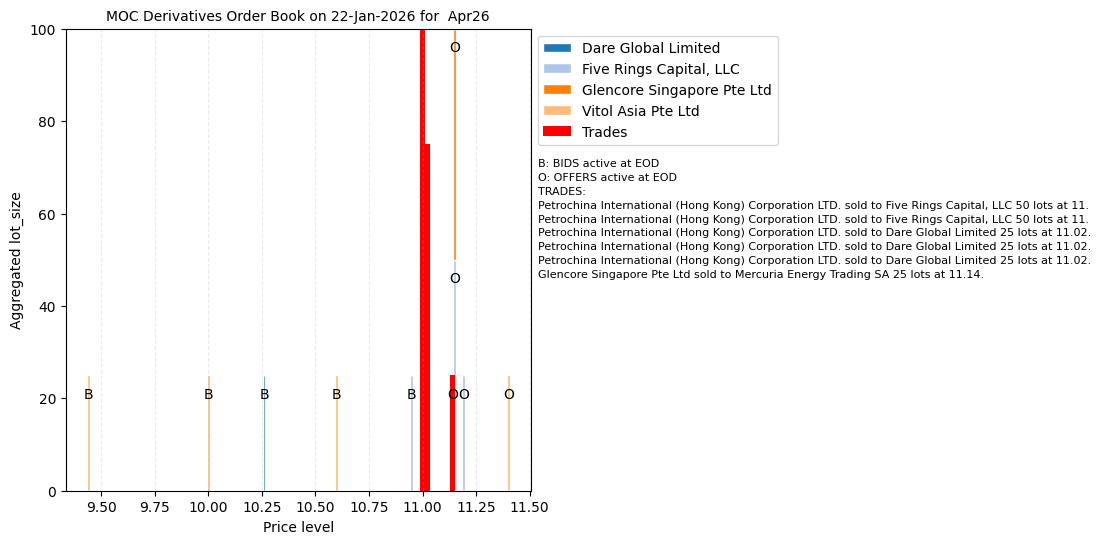

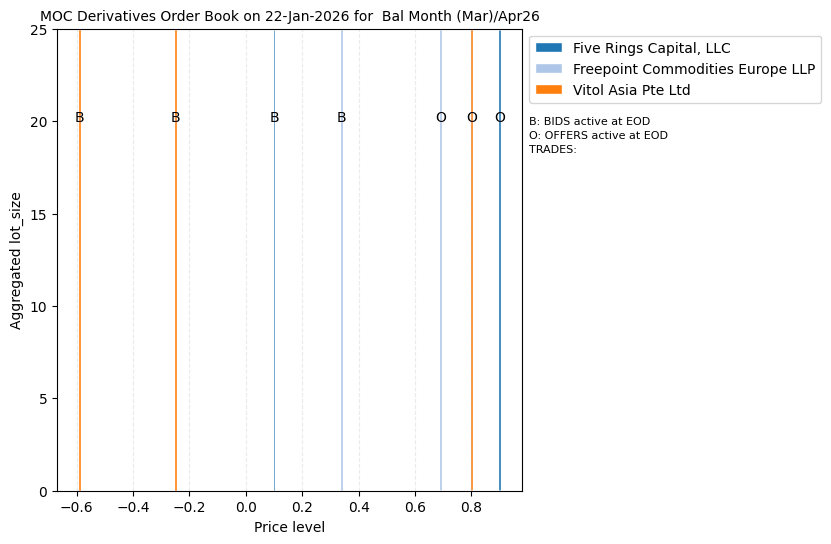

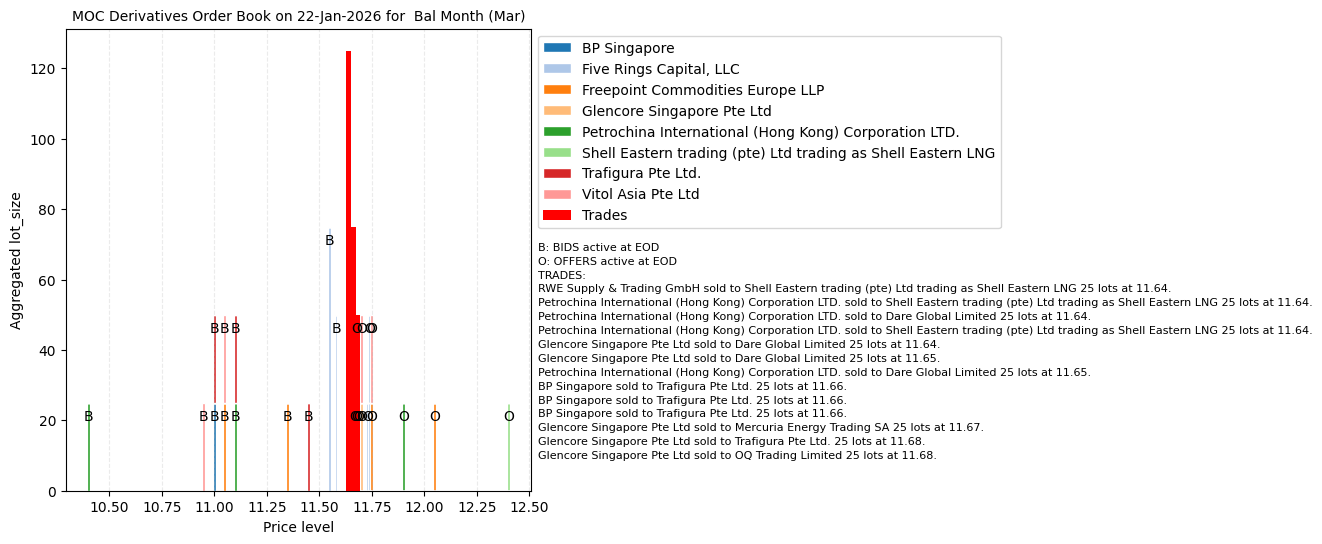

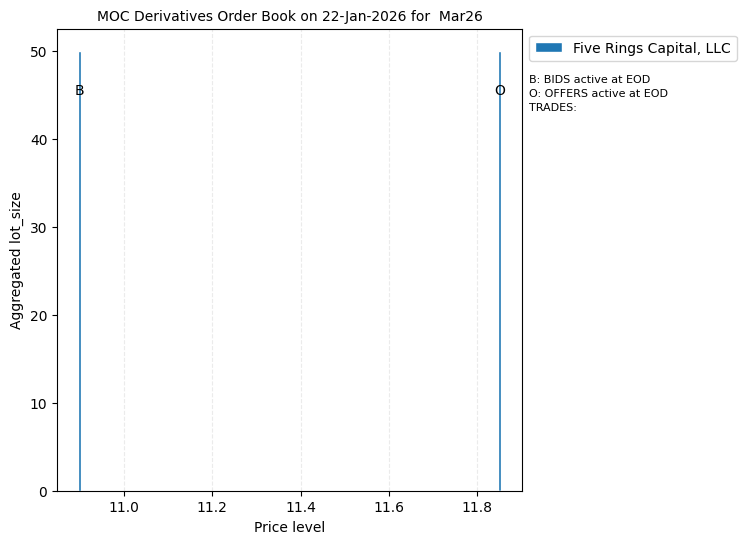

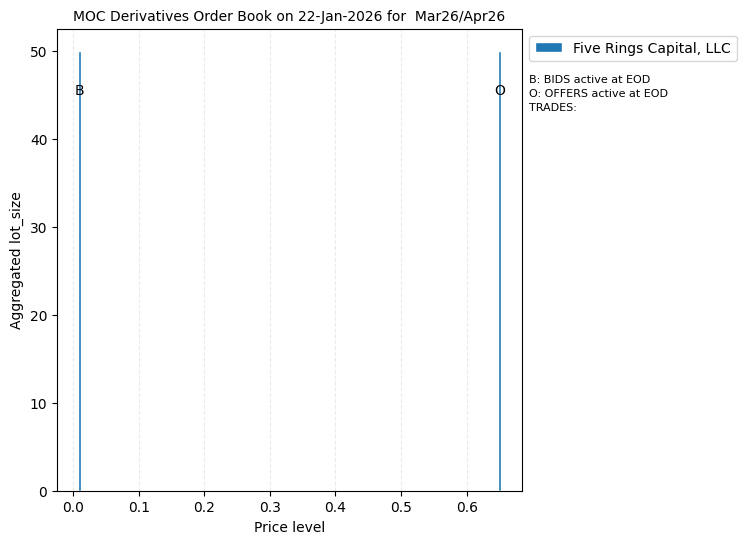

In [183]:

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_orderbook_by_mm(
    df: pd.DataFrame,
    price_col: str = "price",
    qty_col: str = "lot_size",
    order_type_col: str = "order_type",
    state_col: str = "order_state",
    mm_col: str = "market_maker",
    ts_col: str | None = None,
    snapshot_ts=None,                 # e.g. "2026-03-01 12:00:00" or pd.Timestamp
    state: str = "active",            # "Active" for book, "Consummated" for trades
    price_tick: float = 0.01,         # bin size, adjust to market convention
    top_levels: int = 100,             # number of price levels on each side to show
    title: str | None = None,
    figsize=(6, 6)
):
    """
    Creates a stacked horizontal bar chart:
      - y-axis: price levels
      - bids: negative (left)
      - offers: positive (right)
      - stacked by market_maker

    Notes:
      - If ts_col + snapshot_ts provided, filters rows <= snapshot_ts (simple snapshot).
      - If your data is event-based (orders updating), you may need to deduplicate by order_id
        to get the true book at snapshot (see note below).
    """
    d = df.copy()

    # --- filter by state ---
    d = d[d[state_col].eq(state)].copy()

    # basic cleanup
    d = d.dropna(subset=[price_col, qty_col, order_type_col, mm_col])
    d[qty_col] = pd.to_numeric(d[qty_col], errors="coerce")
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce")
    d = d.dropna(subset=[price_col, qty_col])

    # --- bin prices to levels ---
    # Convention:
    #   bids: floor to tick
    #   offers: ceil to tick
    tick = float(price_tick)

    is_bid = d[order_type_col].str.lower().str.contains("bid")
    is_offer = d[order_type_col].str.lower().str.contains("offer")

    d["price_level"] = np.nan
    d.loc[is_bid, "price_level"] = np.floor(d.loc[is_bid, price_col] / tick) * tick
    d.loc[is_offer, "price_level"] = np.ceil(d.loc[is_offer, price_col] / tick) * tick

    d = d.dropna(subset=["price_level"])

    # --- aggregate: price level x mm x side ---
    agg = (
        d.groupby([order_type_col, "price_level", mm_col], as_index=False)[qty_col]
        .sum()
        .rename(columns={qty_col: "qty"})
    )

    # split bids/offers
    bids = agg[agg[order_type_col].str.lower().str.contains("bid")].copy()
    offers = agg[agg[order_type_col].str.lower().str.contains("offer")].copy()

    # choose top price levels per side (closer to mid)
    # We'll take:
    #   bids: highest prices
    #   offers: lowest prices
    bid_levels = sorted(bids["price_level"].unique())
    offer_levels = sorted(offers["price_level"].unique())

    min_bid = min(bid_levels)
    max_offer = max(offer_levels)
    order_size_ticks=(max_offer - min_bid)/150
    trade_size_ticks= order_size_ticks * 2

    bid_levels = bid_levels[-top_levels:] if len(bid_levels) > top_levels else bid_levels
    offer_levels = offer_levels[:top_levels] if len(offer_levels) > top_levels else offer_levels

    bids = bids[bids["price_level"].isin(bid_levels)]
    offers = offers[offers["price_level"].isin(offer_levels)]

    # pivot to price_level x mm (stacked bars)
    bid_piv = bids.pivot_table(index="price_level", columns=mm_col, values="qty", aggfunc="sum", fill_value=0)
    off_piv = offers.pivot_table(index="price_level", columns=mm_col, values="qty", aggfunc="sum", fill_value=0)

    # unify index and columns
    all_levels = sorted(set(bid_piv.index).union(off_piv.index))
    all_mms = sorted(set(bid_piv.columns).union(off_piv.columns))

    bid_piv = bid_piv.reindex(index=all_levels, columns=all_mms, fill_value=0)
    off_piv = off_piv.reindex(index=all_levels, columns=all_mms, fill_value=0)

    # bids should be negative for left plotting
    bid_piv_neg = bid_piv

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    # colors
    cmap = plt.get_cmap("tab20")
    colors = {mm: cmap(i % 20) for i, mm in enumerate(all_mms)}

    # stacked bars: we need running "left" positions
    # Offers (right side)
    off_left = np.zeros(len(all_levels))
    for mm in all_mms:
        vals = off_piv[mm].values
        bar1 = ax.bar(all_levels, vals, bottom=off_left, color=colors[mm], edgecolor="white", width=order_size_ticks, label=mm)
        for rect in bar1:
            height = rect.get_height()
            if height>0:
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height-5, "O", ha='center')
        off_left += vals



    # Bids (left side, negative)
    bid_left = np.zeros(len(all_levels))
    for mm in all_mms:
        vals = bid_piv_neg[mm].values  # negative values
        bar2 = ax.bar(all_levels, vals, bottom=bid_left, color=colors[mm], edgecolor="white", width=order_size_ticks, label=mm)
        for rect in bar2:
            height = rect.get_height()
            if height>0:
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height-5, "B", ha='center')
        bid_left += vals

    # zero line
    # ax.axhline(0, color="black", linewidth=1)

    consumated = df[df["order_state"]=="consummated"].sort_values("price")
    consum_values = consumated.price.values
    buyers = consumated.buyer.values
    sellers = consumated.seller.values
    traded_sizes = consumated.lot_size.values
    unique_prices = {}
    for c, t in zip(consum_values, traded_sizes):
        if c not in unique_prices:
            unique_prices[c] = t
        else:
            unique_prices[c] += t

    if unique_prices:
        ax.bar(unique_prices.keys(), unique_prices.values(), color='red', width=trade_size_ticks, label="Trades")

    subleg_text = []
    for c, b, s, t in zip(consum_values, buyers, sellers, traded_sizes):
        subleg_text.append(f"{s} sold to {b} {t} lots at {c}.\n")

    # formatting
    ax.set_ylabel(f"Aggregated {qty_col}")
    ax.set_xlabel("Price level")
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    # tidy legend (unique only once)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = ax.legend(by_label.values(), by_label.keys(), title="", bbox_to_anchor=(1, 1), loc="upper left")

    offset = matplotlib.text.OffsetFrom(legend, (0.0, 0.0))
    # Create annotation. Top right corner located -20 pixels below the offset point
    # (lower right corner of legend).

    def plot_text_at_y(text, y_offset):
        ax.annotate(text, xy=(0,0), size=8,
                xycoords='figure fraction', xytext=(0,y_offset), textcoords=offset,
                horizontalalignment='left', verticalalignment='top')

    plot_text_at_y("B: BIDS active at EOD", -10)
    plot_text_at_y("O: OFFERS active at EOD", -20)

    plot_text_at_y("TRADES:", -30)
    y_align = -40
    for t in subleg_text:
        plot_text_at_y(t, y_align)
        y_align -= 10

    # nicer x-axis (absolute shown even if negative)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):,.0f}"))

    ax.set_title(title, fontsize=10)

    # plt.tight_layout()
    plt.show()

    return fig, ax

date = "2-Mar-2026"
for tenor in df_filtered.strip.unique():
    df = df_filtered[df_filtered.strip == tenor]
    plot_orderbook_by_mm(
        df,
        title = f"MOC Derivatives Order Book on {date} for {tenor}"
    )


C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_64964\561888503.py:236: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])


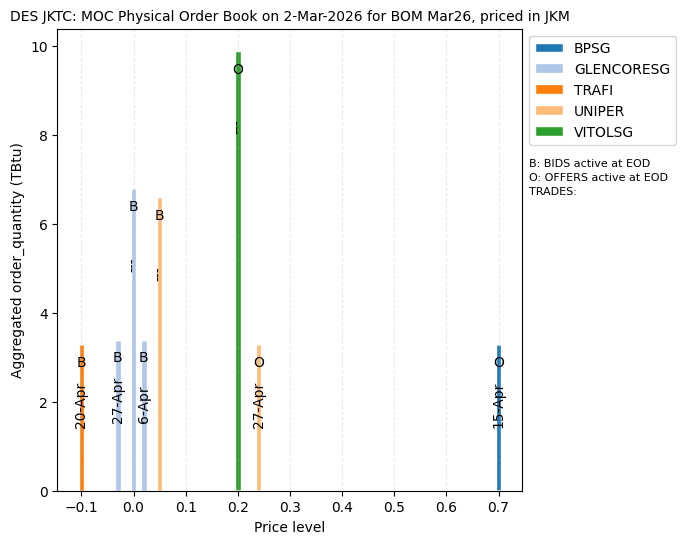

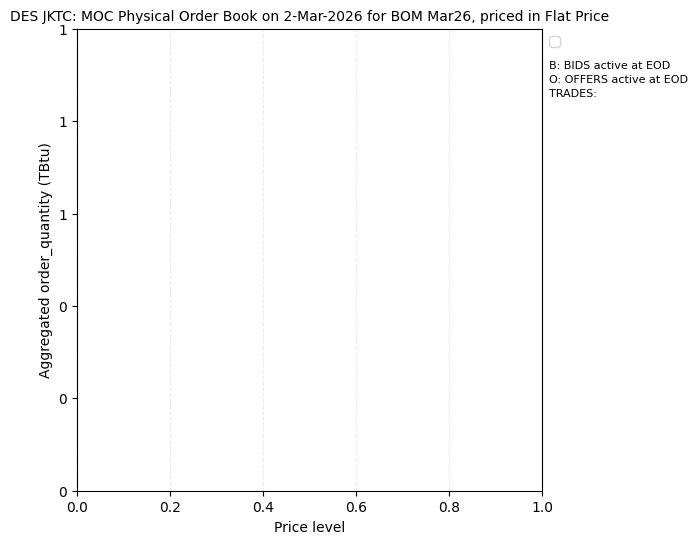

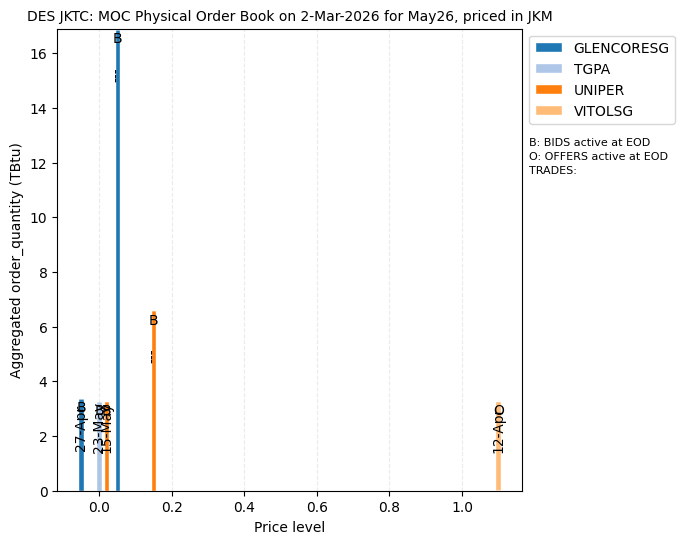

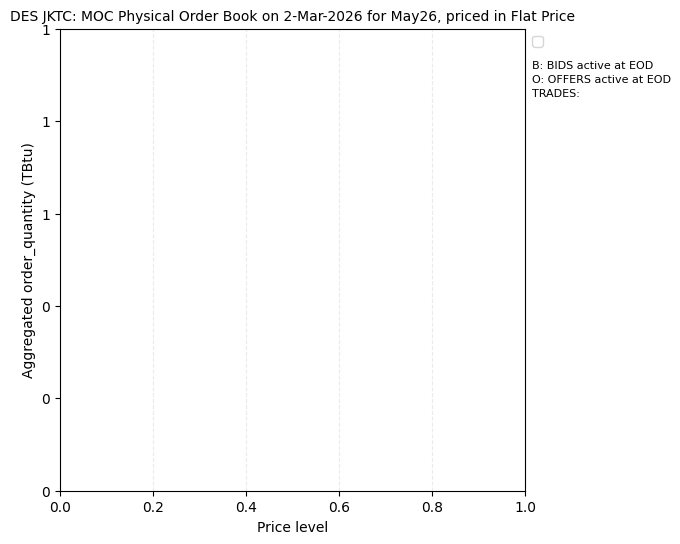

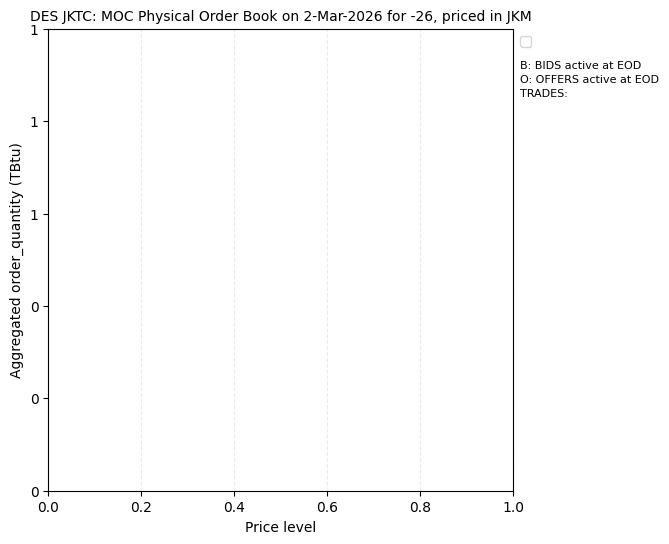

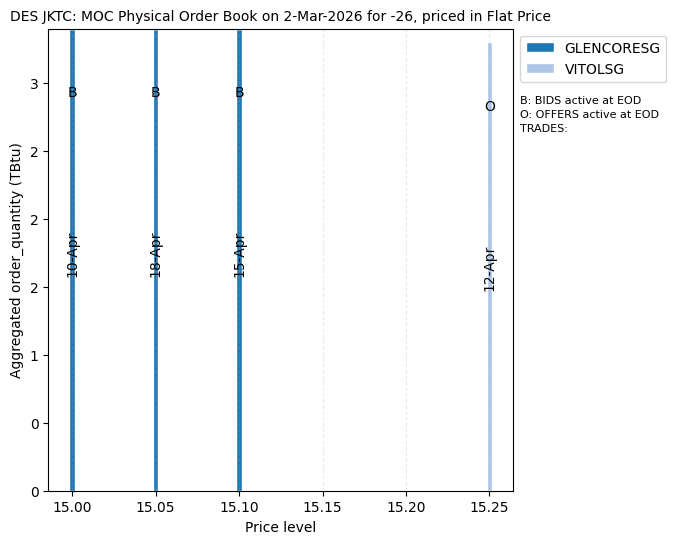

In [12]:

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime


def plot_orderbook_by_mm(
    df: pd.DataFrame,
    price_col: str = "price",
    qty_col: str = "lot_size",
    order_type_col: str = "order_type",
    state_col: str = "order_state",
    mm_col: str = "market_maker",
    ts_col: str | None = None,
    snapshot_ts=None,                 # e.g. "2026-03-01 12:00:00" or pd.Timestamp
    state: str = "active",            # "Active" for book, "Consummated" for trades
    price_tick: float = 0.01,         # bin size, adjust to market convention
    top_levels: int = 100,             # number of price levels on each side to show
    title: str | None = None,
    figsize=(6, 6)
):
    """
    Creates a stacked horizontal bar chart:
      - y-axis: price levels
      - bids: negative (left)
      - offers: positive (right)
      - stacked by market_maker

    Notes:
      - If ts_col + snapshot_ts provided, filters rows <= snapshot_ts (simple snapshot).
      - If your data is event-based (orders updating), you may need to deduplicate by order_id
        to get the true book at snapshot (see note below).
    """
    d = df.copy()

    # --- filter by state ---
    d = d[d[state_col].eq(state)].copy()

    # basic cleanup
    d = d.dropna(subset=[price_col, qty_col, order_type_col, mm_col])
    d[qty_col] = pd.to_numeric(d[qty_col], errors="coerce")
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce")
    d = d.dropna(subset=[price_col, qty_col])

    # --- bin prices to levels ---
    # Convention:
    #   bids: floor to tick
    #   offers: ceil to tick
    tick = float(price_tick)

    is_bid = d[order_type_col].str.lower().str.contains("bid")
    is_offer = d[order_type_col].str.lower().str.contains("offer")

    d["price_level"] = np.nan
    d.loc[is_bid, "price_level"] = np.floor(d.loc[is_bid, price_col] / tick) * tick
    d.loc[is_offer, "price_level"] = np.ceil(d.loc[is_offer, price_col] / tick) * tick

    d = d.dropna(subset=["price_level"])

    # --- aggregate: price level x mm x side ---
    agg = (
        d.groupby([order_type_col, "price_level", mm_col, "order_end"], as_index=False)[qty_col]
        .sum()
        .rename(columns={qty_col: "qty"})
    )

    # split bids/offers
    bids = agg[agg[order_type_col].str.lower().str.contains("bid")].copy()
    offers = agg[agg[order_type_col].str.lower().str.contains("offer")].copy()

    # choose top price levels per side (closer to mid)
    # We'll take:
    #   bids: highest prices
    #   offers: lowest prices
    bid_levels = sorted(bids["price_level"].unique())
    offer_levels = sorted(offers["price_level"].unique())

    if len(bid_levels) == 0:
        min_bid = 8
    else:
        min_bid = min(bid_levels)
    if len(offer_levels) == 0:
        max_offer = 12
    else:
        max_offer = max(offer_levels)

    order_size_ticks=(max_offer - min_bid)/150 * 2
    trade_size_ticks= order_size_ticks * 2

    bid_levels = bid_levels[-top_levels:] if len(bid_levels) > top_levels else bid_levels
    offer_levels = offer_levels[:top_levels] if len(offer_levels) > top_levels else offer_levels

    bids = bids[bids["price_level"].isin(bid_levels)]
    offers = offers[offers["price_level"].isin(offer_levels)]

    # pivot to price_level x mm (stacked bars)
    bid_piv = bids.pivot_table(index="price_level", columns=mm_col, values="qty", aggfunc="sum", fill_value=0)
    off_piv = offers.pivot_table(index="price_level", columns=mm_col, values="qty", aggfunc="sum", fill_value=0)

    # bid_enddates_piv = bids.pivot_table(index="price_level", columns=mm_col, values="order_end", aggfunc="sum", fill_value="---")
    # off_enddates_piv = offers.pivot_table(index="price_level", columns=mm_col, values="order_end", aggfunc="sum", fill_value="---")

    # unify index and columns
    all_levels = sorted(set(bid_piv.index).union(off_piv.index))
    all_mms = sorted(set(bid_piv.columns).union(off_piv.columns))

    bid_piv = bid_piv.reindex(index=all_levels, columns=all_mms, fill_value=0)
    off_piv = off_piv.reindex(index=all_levels, columns=all_mms, fill_value=0)

    # bids should be negative for left plotting
    bid_piv_neg = bid_piv

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    # colors
    cmap = plt.get_cmap("tab20")
    colors = {mm: cmap(i % 20) for i, mm in enumerate(all_mms)}

    int_to_month = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
              7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}

    # stacked bars: we need running "left" positions
    # Offers (right side)
    off_left = np.zeros(len(all_levels))
    for mm in all_mms:
        vals = off_piv[mm].values
        bar1 = ax.bar(all_levels, vals, bottom=off_left, color=colors[mm], edgecolor="white", width=order_size_ticks, label=mm)

        for idx, rect in enumerate(bar1):
            height = rect.get_height()
            if height>0:
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height-0.5, "O", ha='center')
                price = all_levels[idx]
                order_size = vals[idx]
                end_date = agg[(agg["price_level"]==price) & (agg["market_maker_mnemonic"]==mm) & (agg["qty"]==order_size) & (agg["order_type"]=="Offer")].order_end
                if len(end_date):
                    end_date = end_date.iloc[0]
                    end_date_str = str(end_date.day) + "-" + int_to_month[end_date.month]
                else:
                    end_date_str = "---"
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height-1.8, end_date_str, ha='center', rotation=90)

        off_left += vals



    # Bids (left side, negative)
    bid_left = np.zeros(len(all_levels))
    for mm in all_mms:
        vals = bid_piv_neg[mm].values  # negative values
        bar2 = ax.bar(all_levels, vals, bottom=bid_left, color=colors[mm], edgecolor="white", width=order_size_ticks, label=mm)
        for idx, rect in enumerate(bar2):
            height = rect.get_height()
            if height>0:
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height -0.5, "B", ha='center')
                price = all_levels[idx]
                order_size = vals[idx]
                end_date = agg[(agg["price_level"]==price) & (agg["market_maker_mnemonic"]==mm) & (agg["qty"]==order_size) & (agg["order_type"]=="Bid")].order_end
                if len(end_date):
                    end_date = end_date.iloc[0]
                    end_date_str = str(end_date.day) + "-" + int_to_month[end_date.month]
                else:
                    end_date_str = "---"
                plt.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + height-1.8, end_date_str, ha='center', rotation=90)
        bid_left += vals

    # zero line
    # ax.axhline(0, color="black", linewidth=1)

    consumated = df[df["order_state"]=="consummated"].sort_values("c1_price")
    consum_values = consumated.c1_price.values
    buyers = consumated.buyer_mnemonic.values
    sellers = consumated.seller_mnemonic.values
    order_dates = consumated.order_end.values
    traded_sizes = consumated.order_quantity.values
    unique_prices = {}
    for c, t in zip(consum_values, traded_sizes):
        if c not in unique_prices:
            unique_prices[c] = t
        else:
            unique_prices[c] += t

    if unique_prices:
            ax.bar(unique_prices.keys(), unique_prices.values(), color='red', alpha=0.8, width=trade_size_ticks, label="Trades")

    subleg_text = []
    for c, b, s, t, end_date in zip(consum_values, buyers, sellers, traded_sizes, order_dates):
        subleg_text.append(f"{s} sold to {b} {t} TBtu at {c} for {str(end_date)[:10]}.\n")

    # formatting
    ax.set_ylabel(f"Aggregated {qty_col} (TBtu)")
    ax.set_xlabel("Price level")
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    # tidy legend (unique only once)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = ax.legend(by_label.values(), by_label.keys(), title="", bbox_to_anchor=(1, 1), loc="upper left")

    offset = matplotlib.text.OffsetFrom(legend, (0.0, 0.0))
    # Create annotation. Top right corner located -20 pixels below the offset point
    # (lower right corner of legend).

    def plot_text_at_y(text, y_offset):
        ax.annotate(text, xy=(0,0), size=8,
                xycoords='figure fraction', xytext=(0,y_offset), textcoords=offset,
                horizontalalignment='left', verticalalignment='top')

    plot_text_at_y("B: BIDS active at EOD", -10)
    plot_text_at_y("O: OFFERS active at EOD", -20)

    plot_text_at_y("TRADES:", -30)
    y_align = -40
    for t in subleg_text:
        plot_text_at_y(t, y_align)
        y_align -= 10

    # nicer x-axis (absolute shown even if negative)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):,.0f}"))

    ax.set_title(title, fontsize=10)

    # plt.tight_layout()
    plt.show()

    return fig, ax

import pandas as pd
file_path = "C:\\Marti\\PlattsMOC\\platts_MOC_2Mar2026_pyhsical.xlsx"
df = pd.read_excel(file_path)
df = df[df.order_state != "inactive"]
# df = df[df.order_state != "withdrawn"]
df_filtered = df.groupby('order_id', group_keys=False).apply(lambda x: x.loc[x.update_time.idxmax()])
df_filtered = df_filtered[df_filtered.order_state != "withdrawn"]

date = "2-Mar-2026"
first_contract = "BOM Mar26"
year = "26"
for tenor in df_filtered.c1_basis_period_details.unique():
    for price_basis in df_filtered.c1_price_basis.unique():
        for hub in df_filtered.hub.unique():
            df = df_filtered[df_filtered.c1_basis_period_details == tenor]
            df = df[df.c1_price_basis == price_basis]
            df = df[df.hub == hub]

            _tenor = tenor+year if tenor != "Next Day" else first_contract
            plot_orderbook_by_mm(
                df,
                qty_col = "order_quantity",
                mm_col="market_maker_mnemonic",
                price_col="c1_price",
                title = f"{hub}: MOC Physical Order Book on {date} for {_tenor}, priced in {price_basis}",
            )

In [68]:
df_filtered.order_end

order_id
111423984   2026-03-25
114142900   2026-03-19
123183330   2026-03-12
127491569   2026-03-22
132136300   2026-03-22
171732717   2026-03-18
186845531   2026-03-15
187101122   2026-04-14
188504175   2026-03-14
197143200   2026-03-15
215343121   2026-03-14
275254587   2026-03-22
288474852   2026-03-15
296896821   2026-03-18
310841778   2026-03-23
317283699   2026-03-26
395202598   2026-04-05
476637646   2026-03-05
486292108   2026-03-08
486881274   2026-03-05
505803430   2026-03-20
640219724   2026-04-10
679567538   2026-03-27
743144513   2026-03-05
858582759   2026-03-10
867312279   2026-03-12
920457359   2026-03-08
989049260   2026-03-18
Name: order_end, dtype: datetime64[ns]